In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os.path
from scipy.spatial.distance import cdist
import time
from tqdm import tqdm
import pandas as pd

In [12]:
pr_set_len = pd.read_csv("pr_allvsall_lol.rocx", sep='\t')
pr_set_len_pref = pd.read_csv("pr_allvsall_lolpref.rocx", sep='\t')
fs = pd.read_csv("pr_allvsall_fs.rocx", sep='\t')
pr_dali = pd.read_csv('dali.rocx', sep='\t')
tm = pd.read_csv("pr_allvsall_tm.rocx", sep='\t')
tmpref = pd.read_csv("pr_allvsall_tmpref.rocx", sep='\t')

colors = {
    "Dali": "#FFA500",           
    "TM-align": "#138BD1",       
    "Foldseek": "#00AA00",       
    "LoLalign": "#FF0000",       
    "Foldseek-LoL": "#FF1493",   
    "Foldseek-Tm": "#9932CC"     
}

# Publication-quality figure settings
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'font.size': 12,
    'axes.labelsize': 20,
    'axes.titlesize': 16,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5,
    'grid.alpha': 0.3,
    'figure.dpi': 100
})



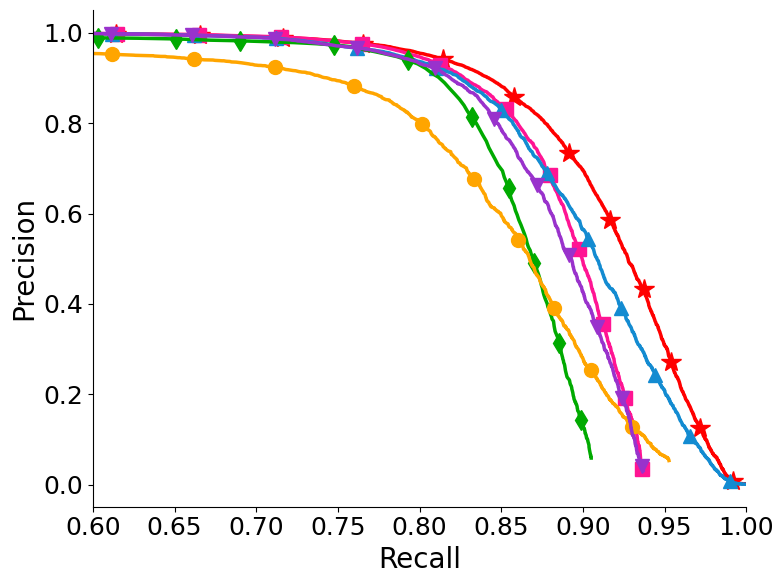

In [15]:
plt.plot(pr_set_len['RECALL_FAM'], pr_set_len['PREC_FAM'],label= 'LoLalign', color=colors["LoLalign"], linewidth=2.5,
         marker='*', markersize=15, markevery=0.1)
plt.plot(pr_set_len_pref['RECALL_FAM'], pr_set_len_pref['PREC_FAM'],label= 'Foldseek-LoL', color = colors["Foldseek-LoL"], linewidth=2.5,
         marker='s', markersize=10, markevery=0.1)
plt.plot(tm['RECALL_FAM'], tm['PREC_FAM'], label= 'TM-align', color = colors["TM-align"], linewidth=2.5,
         marker='^', markersize=10, markevery=0.1)
plt.plot(fs['RECALL_FAM'], fs['PREC_FAM'],label= 'Foldseek', color = colors["Foldseek"], linewidth=2.5,
         marker='d', markersize=10, markevery=0.1)
plt.plot(pr_dali['RECALL_FAM'], pr_dali['PREC_FAM'],label= 'Dali', color = colors["Dali"], linewidth=2.5,
         marker='o', markersize=10, markevery=0.1)
plt.plot(tmpref['RECALL_FAM'], tmpref['PREC_FAM'], label= 'Foldseek-TM', color = colors["Foldseek-Tm"], linewidth=2.5,
         marker='v', markersize=10, markevery=0.1)

plt.xlabel("Recall", fontsize=20)
plt.ylabel("Precision", fontsize=20)
#plt.title("Family")
plt.xlim(0.6, 1)

plt.tick_params(labelsize=18)


# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#plt.legend()
plt.tight_layout()
plt.savefig('pr_fam.jpg', dpi=400)

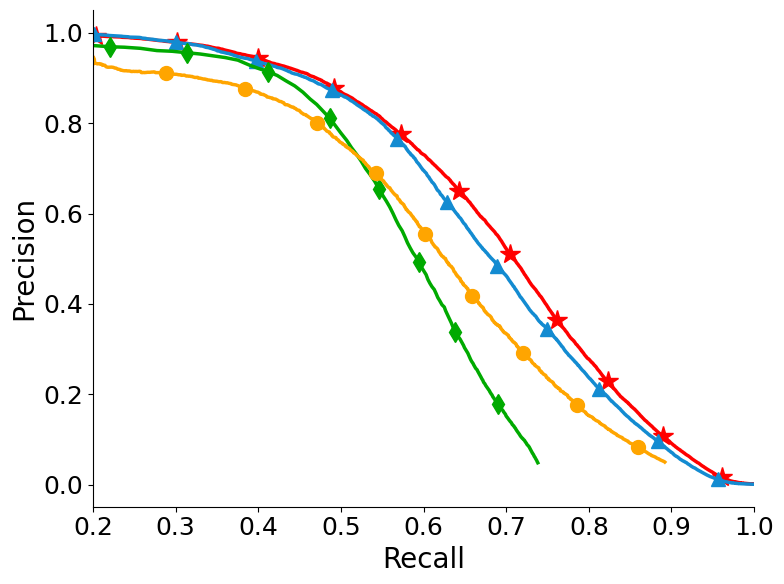

In [14]:
plt.plot(pr_set_len['RECALL_SFAM'], pr_set_len['PREC_SFAM'],label= 'LoLalign', color=colors["LoLalign"], linewidth=2.5,
         marker='*', markersize=15, markevery=0.1)
#plt.plot(pr_set_len_pref['RECALL_SFAM'], pr_set_len_pref['PREC_SFAM'],label= 'Foldseek-LoL', color = colors["Foldseek-LoL"], linewidth=2.5,
#         marker='s', markersize=10, markevery=0.1)
plt.plot(tm['RECALL_SFAM'], tm['PREC_SFAM'], label= 'TM-align', color = colors["TM-align"], linewidth=2.5,
         marker='^', markersize=10, markevery=0.1)
plt.plot(fs['RECALL_SFAM'], fs['PREC_SFAM'],label= 'Foldseek', color = colors["Foldseek"], linewidth=2.5,
         marker='d', markersize=10, markevery=0.1)
plt.plot(pr_dali['RECALL_SFAM'], pr_dali['PREC_SFAM'],label= 'Dali', color = colors["Dali"], linewidth=2.5,
         marker='o', markersize=10, markevery=0.1)
#plt.plot(tmpref['RECALL_SFAM'], tmpref['PREC_SFAM'], label= 'Foldseek-TM', color = colors["Foldseek-Tm"], linewidth=2.5,
#         marker='v', markersize=10, markevery=0.1)

plt.xlabel("Recall", fontsize=20)
plt.ylabel("Precision", fontsize=20)
#plt.title("Family")
#plt.legend(frameon=True, fancybox=True, shadow=True,
#           loc='lower left', fontsize=18)
plt.xlim(0.2, 1)

plt.tick_params(labelsize=18)


# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#(ax.text(-0.1, 1.05, 'b', transform=ax.transAxes, fontsize=24, fontweight='bold', va='top', ha='right'))


plt.tight_layout()
plt.savefig('pr_sfam.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('pr_sfam.png', dpi=300, bbox_inches='tight', format='png')


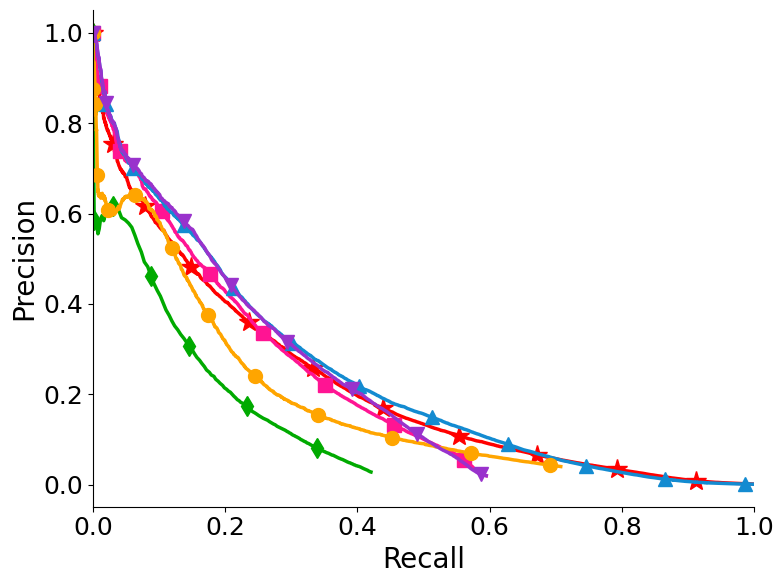

In [34]:
plt.plot(pr_set_len['RECALL_FOLD'], pr_set_len['PREC_FOLD'],label= 'LoLalign', color=colors["LoLalign"], linewidth=2.5,
         marker='*', markersize=15, markevery=0.1)
plt.plot(pr_set_len_pref['RECALL_FOLD'], pr_set_len_pref['PREC_FOLD'],label= 'Foldseek-LoL', color = colors["Foldseek-LoL"], linewidth=2.5,
         marker='s', markersize=10, markevery=0.1)
plt.plot(tm['RECALL_FOLD'], tm['PREC_FOLD'], label= 'TM-align', color = colors["TM-align"], linewidth=2.5,
         marker='^', markersize=10, markevery=0.1)
plt.plot(fs['RECALL_FOLD'], fs['PREC_FOLD'],label= 'Foldseek', color = colors["Foldseek"], linewidth=2.5,
         marker='d', markersize=10, markevery=0.1)
plt.plot(pr_dali['RECALL_FOLD'], pr_dali['PREC_FOLD'],label= 'Dali', color = colors["Dali"], linewidth=2.5,
         marker='o', markersize=10, markevery=0.1)
plt.plot(tmpref['RECALL_FOLD'], tmpref['PREC_FOLD'], label= 'Foldseek-TM', color = colors["Foldseek-Tm"], linewidth=2.5,
         marker='v', markersize=10, markevery=0.1)

plt.xlabel("Recall", fontsize=20)
plt.ylabel("Precision", fontsize=20)
#plt.title("Family")
plt.xlim(0, 1)

plt.tick_params(labelsize=18)


# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig('pr_fold.jpg', dpi=400)